# Evaluating Trained FM Models' Performance

In [ ]:
import os
import sys

from corner import corner

sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.distributions import Prior, Posterior
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN, LightCurveThinner, fourier_embedding
from src.helpers import record_every, plot_posterior_samples

import numpy as np
import torch
import yaml

from src.flow_matching.plotting import plot_loss, plot_snapshots
from src.flow_matching.helpers import choose_device, build_mlp

device = choose_device()

In [2]:
MODELS = {
    "MLPGuidedVectorField": MLPGuidedVectorField
}

TIME_ENCODERS = {
    "LightCurveThinner": LightCurveThinner,
    "FRBLightCurveCNN": FRBLightCurveCNN
}

TAU_ENCODERS = {
    True : fourier_embedding,
    False : None 
}

THETA_ENCODERS = {
    True : lambda theta_dim : build_mlp([2] + [2 * 4, 2 * 8] + [theta_dim]),
    False : None
}

In [3]:
# loading the model (via run_id, or path)
job_id = "1234567" #False
run_dir = None
save_dir = "../checkpoints/"

def find_run_dir(job_id:str, save_dir: str) -> str | None:
    """
    Returns path to folder where run was saved.
    """
    for dir_name in os.listdir(save_dir):
        if job_id in dir_name:
            return os.path.join(save_dir, dir_name)
    return None

run_dir = find_run_dir(job_id, save_dir) if job_id else os.path.join(save_dir, run_dir)

checkpoint_path = os.path.join(run_dir, 'training_checkpoint.pth')
config_path     = os.path.join(run_dir, 'config.yaml')

In [4]:
# I need all the args needed to init the model (and encoders..)
# TODO: add func: load from config?

# create empty model from config
def empty_model_from_config(path):
    with open(path, 'r') as f:
        config = yaml.safe_load(f)
    
    model_name = config["model"]["name"]
    model_class = MODELS[model_name]
    
    kwargs = config["model"]["init_params"]

    time_encoder = config["time_seq_encoder"]["name"]
    t_encoder_kwargs = config["time_seq_encoder"]["init_params"]


    kwargs['time_seq_encoder']  = TIME_ENCODERS[time_encoder](**t_encoder_kwargs)
    kwargs['tau_encoder']   = TAU_ENCODERS[config["tau_encoder"]]
    kwargs['theta_encoder'] = THETA_ENCODERS[config["theta_encoder"]]
    
    return model_class(**kwargs)

vector_field = empty_model_from_config(config_path)

In [5]:
# load trained model 
checkpoint = torch.load(checkpoint_path)
vector_field.load_state_dict(checkpoint["model_state_dict"])
vector_field.eval()
vector_field.to(device)

losses = checkpoint["losses"]

# Loss

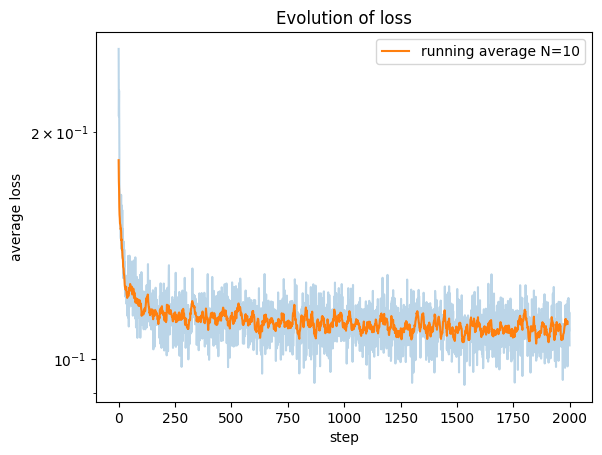

In [6]:
plot_loss(losses, window_size=10, xlog=False)

# Example posterior

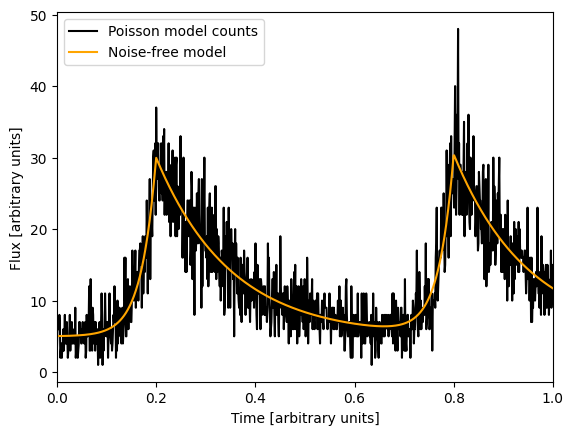

In [7]:
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 25.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.2, 0.8] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    "time": time,
    "ncomp": N,
    "burstparams":burstparams,
    "ybkg":ybkg
}

# generate one instance of simulated data to guide prior samples with
model = Model(**modelparams)
simulator = BurstSimulator(model)
x_counts = simulator.simulate_burst() 
simulator.plot_burst()

100%|██████████| 99/99 [00:00<00:00, 341.26it/s]


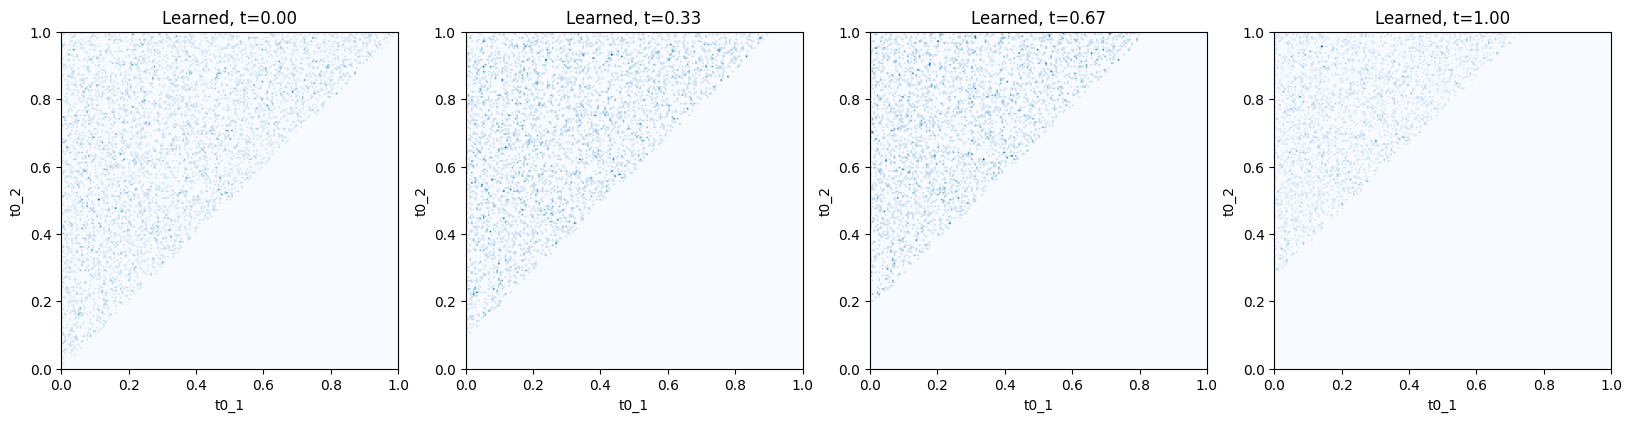

In [8]:
# Cell to generate posteriors for given peaktime (corner plot & histogram)
num_samples = 5000  # number of prior samples to transform 
num_marginals = 4   # number of snapshots

# TODO: maybe do this in batches
# use same data point for conditioning all prior samples
simulations = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(num_samples, 1)

# initialize ODE solver
solver = EulerODESolver(vector_field)
nts = 100
ts = torch.linspace(0, 1, nts).to(device)

path = GuidedLinearProbabilityPath(
        p_simple=Prior(),
        p_data=Posterior()
    )

# simulate ODE starting from x0
x0 = path.p_simple.sample(num_samples).to(device)
xts = solver.solve_with_trajectory(x0, ts.view(1, nts, 1).expand(num_samples, nts, 1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(nts, nts // (num_marginals - 1))
xts = xts[:, record_every_idxs, :]

# plot snapshots of marginal path
final_snapshot = plot_snapshots(xts, ts, record_every_idxs, num_marginals)

# corner plot

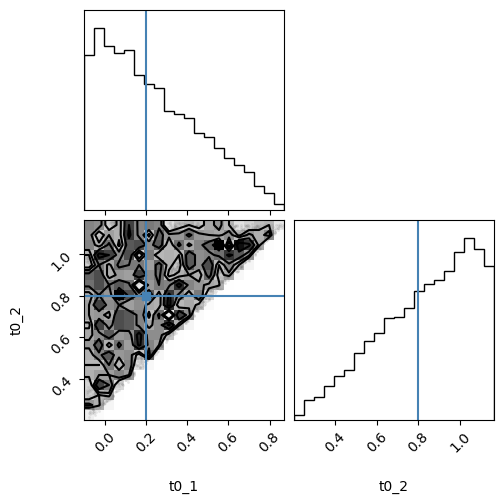

In [9]:
fig = corner(final_snapshot.cpu().numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0))

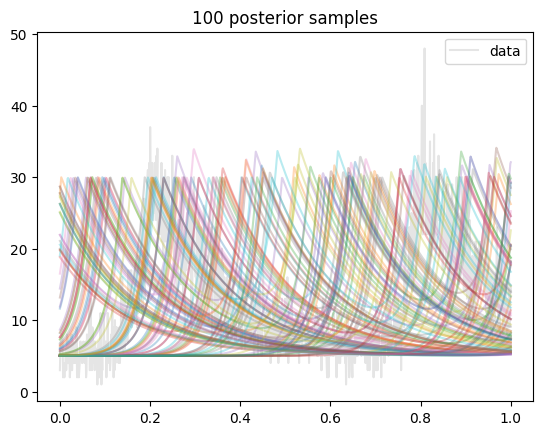

In [10]:
# Cell to overlay posterior samples on data
plot_posterior_samples(100, x_counts, final_snapshot.cpu().numpy(), ["t0"], modelparams)

# PP-plot

In [ ]:
# cell for PP-plot